# Tugas 1A — Notebook Pertamaku

**Mata Kuliah:** Machine Learning & AI  
**Dataset:** Wine (scikit-learn)

**Nama :** Fadjar Ahmad Novfandi

**NIM :** 2553150006

Tujuan: mengulang pipeline Iris pada pertemuan 1 menggunakan dataset Wine, membuat 5 visualisasi, melakukan train/test split, melatih model, dan membaca classification report.

In [1]:
# Identitas
NIM = "2553150006"
NAMA = "Fadjar Ahmad Novfandi"
print("NIM:", NIM)
print("Nama:", NAMA)

NIM: 2553150006
Nama: Fadjar Ahmad Novfandi


## 1. Import library

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

plt.rcParams["figure.figsize"] = (8, 5)

## 2. Memuat dataset Wine

In [3]:
wine = load_wine(as_frame=True)
df = wine.frame.copy()
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])
print("\nNama fitur:")
print(list(wine.feature_names))
print("\nDistribusi target:")
print(df["target"].value_counts().sort_index())

Jumlah baris: 178
Jumlah kolom: 14

Nama fitur:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Distribusi target:
target
0    59
1    71
2    48
Name: count, dtype: int64


## 3. T / E / P

- **T (Task):** memprediksi kelas/spesies wine dari karakteristik kimianya.
- **E (Experience):** data Wine yang tersedia, terdiri dari 178 sampel dengan fitur kimia dan label kelas.
- **P (Performance):** akurasi dan classification report pada data test yang belum digunakan saat training.

## 4. Lima visualisasi data

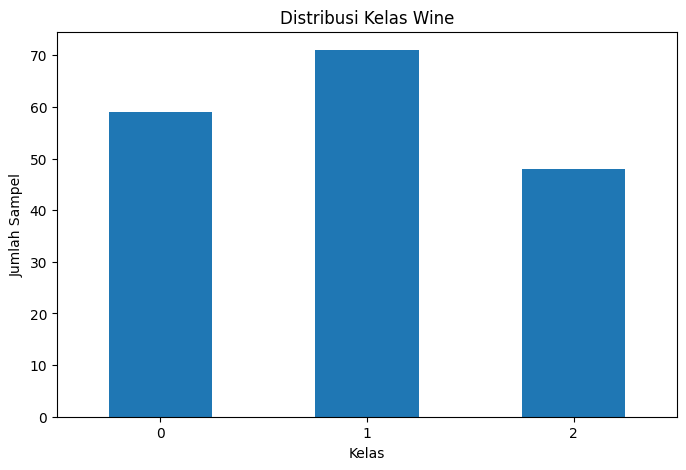

In [5]:
# Visualisasi 1 — distribusi kelas
df["target"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribusi Kelas Wine")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Sampel")
plt.xticks(rotation=0)
plt.show()

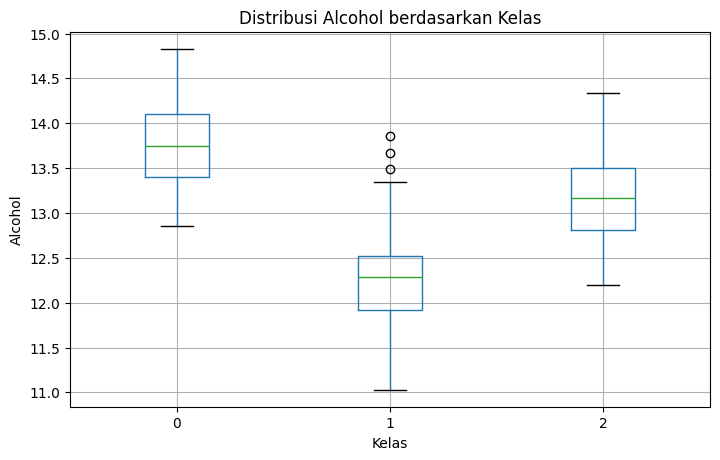

In [6]:
# Visualisasi 2 — alcohol per kelas
df.boxplot(column="alcohol", by="target")
plt.title("Distribusi Alcohol berdasarkan Kelas")
plt.suptitle("")
plt.xlabel("Kelas")
plt.ylabel("Alcohol")
plt.show()

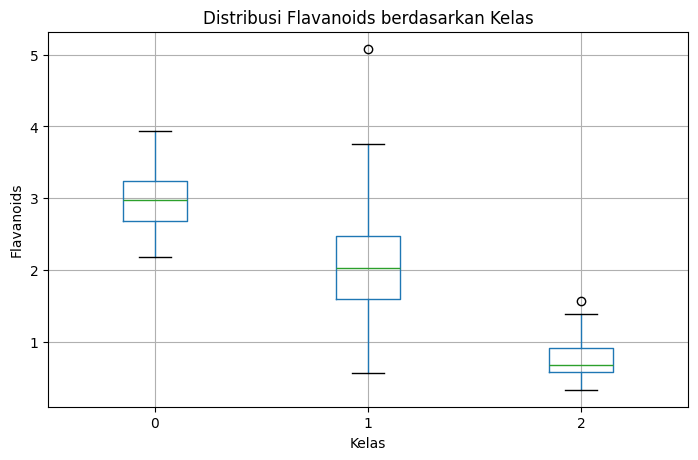

In [7]:
# Visualisasi 3 — flavanoids per kelas
df.boxplot(column="flavanoids", by="target")
plt.title("Distribusi Flavanoids berdasarkan Kelas")
plt.suptitle("")
plt.xlabel("Kelas")
plt.ylabel("Flavanoids")
plt.show()

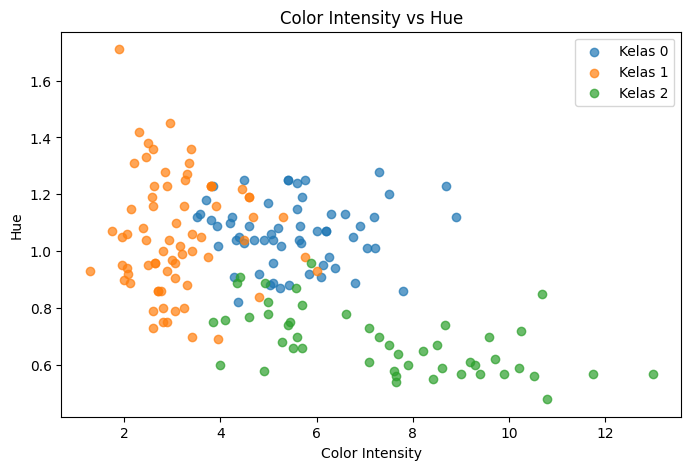

In [8]:
# Visualisasi 4 — color_intensity vs hue
for cls in sorted(df["target"].unique()):
    subset = df[df["target"] == cls]
    plt.scatter(subset["color_intensity"], subset["hue"], label=f"Kelas {cls}", alpha=0.7)
plt.title("Color Intensity vs Hue")
plt.xlabel("Color Intensity")
plt.ylabel("Hue")
plt.legend()
plt.show()

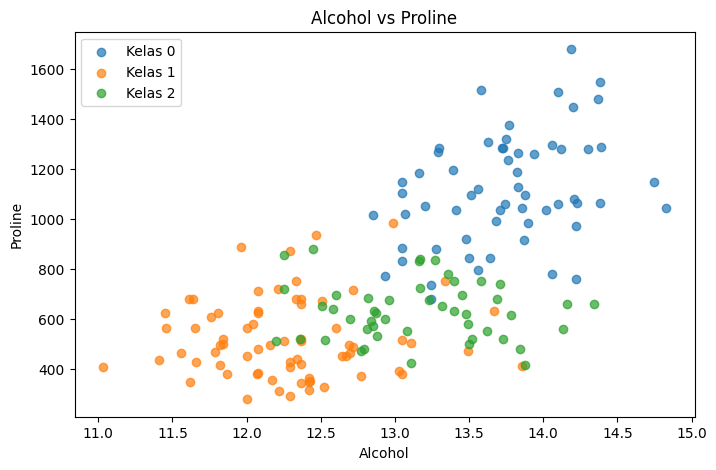

In [9]:
# Visualisasi 5 — hubungan proline dan alcohol
for cls in sorted(df["target"].unique()):
    subset = df[df["target"] == cls]
    plt.scatter(subset["alcohol"], subset["proline"], label=f"Kelas {cls}", alpha=0.7)
plt.title("Alcohol vs Proline")
plt.xlabel("Alcohol")
plt.ylabel("Proline")
plt.legend()
plt.show()

## 5. Train/Test Split

Data dibagi menjadi 70% data training dan 30% data testing. Data test disimpan untuk menguji kemampuan model pada data yang belum pernah dilihat.

In [10]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Data training:", X_train.shape)
print("Data testing :", X_test.shape)

Data training: (124, 13)
Data testing : (54, 13)


## 6. Melatih model K-Nearest Neighbors

In [11]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Akurasi:", round(accuracy, 4))

Akurasi: 0.6852


## 7. Classification Report

In [12]:
print(classification_report(
    y_test,
    y_pred,
    target_names=wine.target_names
))

              precision    recall  f1-score   support

     class_0       0.85      0.94      0.89        18
     class_1       0.67      0.67      0.67        21
     class_2       0.46      0.40      0.43        15

    accuracy                           0.69        54
   macro avg       0.66      0.67      0.66        54
weighted avg       0.67      0.69      0.68        54



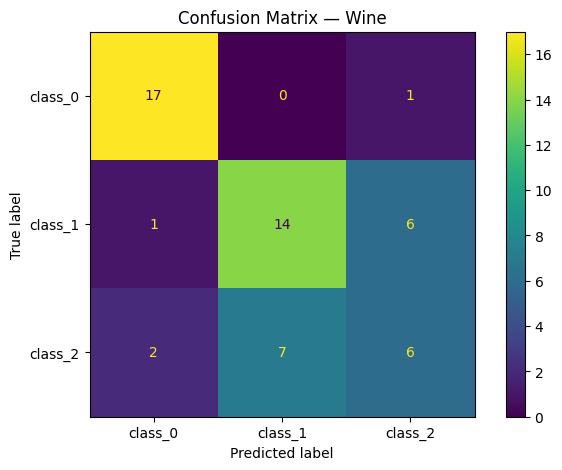

In [13]:
# Confusion matrix sebagai pemeriksaan tambahan
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=wine.target_names)
disp.plot()
plt.title("Confusion Matrix — Wine")
plt.show()

## 8. Kesimpulan

Model KNN digunakan untuk memprediksi kelas Wine berdasarkan fitur-fitur kimia. Nilai akurasi dan classification report digunakan untuk melihat performa pada data test. Karena data test tidak digunakan saat proses training, hasilnya memberikan gambaran kemampuan generalisasi model pada data yang belum pernah dilihat.

# Tugas 1B — Jadi Detektif Bias Data
**Dataset:** Adult Income — UCI Machine Learning Repository

Tujuan: menghitung persentase orang berpenghasilan >50K berdasarkan gender dan ras, membuat minimal 3 grafik, lalu menganalisis risiko bias jika data digunakan untuk AI persetujuan kredit.

## 1. Import library

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

pd.set_option("display.max_columns", None)

## 2. Memuat Adult Income

Dataset resmi Adult dari UCI memiliki 48.842 instance dan 14 fitur, dengan target apakah pendapatan tahunan melebihi $50K. Dataset juga memiliki missing values. Pada notebook ini, data dibaca langsung dari file `adult.data` dan `adult.test` UCI.

In [15]:
columns = [
    "age","workclass","fnlwgt","education","education-num","marital-status",
    "occupation","relationship","race","sex","capital-gain","capital-loss",
    "hours-per-week","native-country","income"
]

train_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
test_url  = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test"

train = pd.read_csv(train_url, header=None, names=columns, na_values=" ?", skipinitialspace=True)
test = pd.read_csv(test_url, header=None, names=columns, na_values=" ?", skipinitialspace=True, skiprows=1)

df = pd.concat([train, test], ignore_index=True)
df["income"] = df["income"].str.replace(".", "", regex=False).str.strip()

print("Ukuran dataset:", df.shape)
df.head()

Ukuran dataset: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 3. Pembersihan data

In [16]:
# Cek missing values
missing = df.isna().sum().sort_values(ascending=False)
print(missing[missing > 0])

# Buang baris yang missing pada variabel yang dipakai
analysis = df.dropna(subset=["sex", "race", "income"]).copy()

print("Jumlah data setelah pembersihan:", len(analysis))
print(analysis[["sex","race","income"]].head())

Series([], dtype: int64)
Jumlah data setelah pembersihan: 48842
      sex   race income
0    Male  White  <=50K
1    Male  White  <=50K
2    Male  White  <=50K
3    Male  Black  <=50K
4  Female  Black  <=50K


## 4. Persentase income >50K berdasarkan gender

In [17]:
gender_table = pd.crosstab(
    analysis["sex"], analysis["income"], normalize="index"
) * 100

print(gender_table.round(2))

gender_high = (
    analysis.assign(high_income=analysis["income"].eq(">50K"))
    .groupby("sex")["high_income"]
    .mean() * 100
)

print("\nPersentase income >50K berdasarkan gender:")
print(gender_high.round(2))

income  <=50K   >50K
sex                 
Female  89.07  10.93
Male    69.62  30.38

Persentase income >50K berdasarkan gender:
sex
Female    10.93
Male      30.38
Name: high_income, dtype: float64


## 5. Persentase income >50K berdasarkan ras

In [19]:
race_high = (
    analysis.assign(high_income=analysis["income"].eq(">50K"))
    .groupby("race")["high_income"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("Persentase income >50K berdasarkan ras:")
print(race_high.round(2))

Persentase income >50K berdasarkan ras:
race
Asian-Pac-Islander    26.93
White                 25.40
Other                 12.32
Black                 12.08
Amer-Indian-Eskimo    11.70
Name: high_income, dtype: float64


## 6. Minimal 3 visualisasi

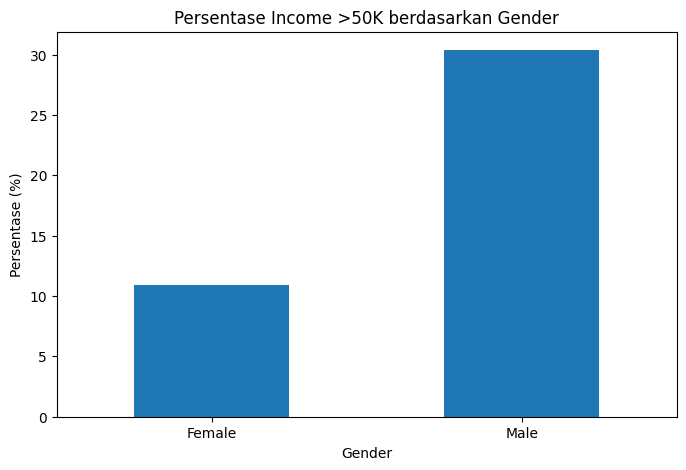

In [20]:
# Grafik 1 — income >50K berdasarkan gender
gender_high.sort_values().plot(kind="bar")
plt.title("Persentase Income >50K berdasarkan Gender")
plt.xlabel("Gender")
plt.ylabel("Persentase (%)")
plt.xticks(rotation=0)
plt.show()

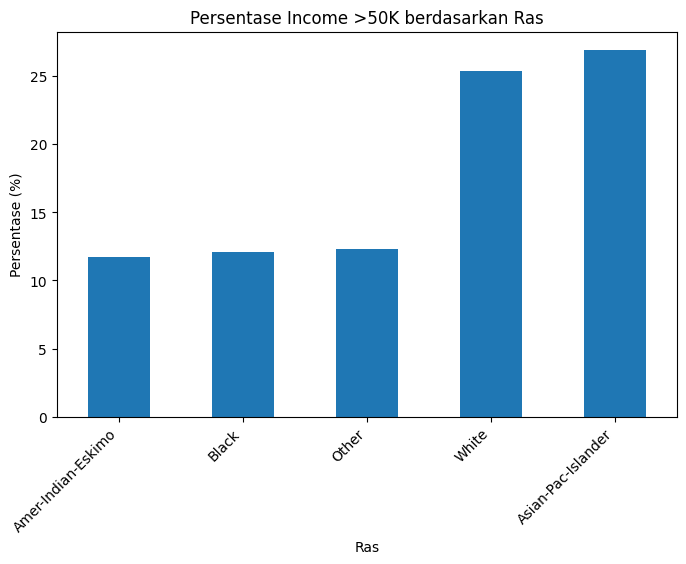

In [21]:
# Grafik 2 — income >50K berdasarkan ras
race_high.sort_values().plot(kind="bar")
plt.title("Persentase Income >50K berdasarkan Ras")
plt.xlabel("Ras")
plt.ylabel("Persentase (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

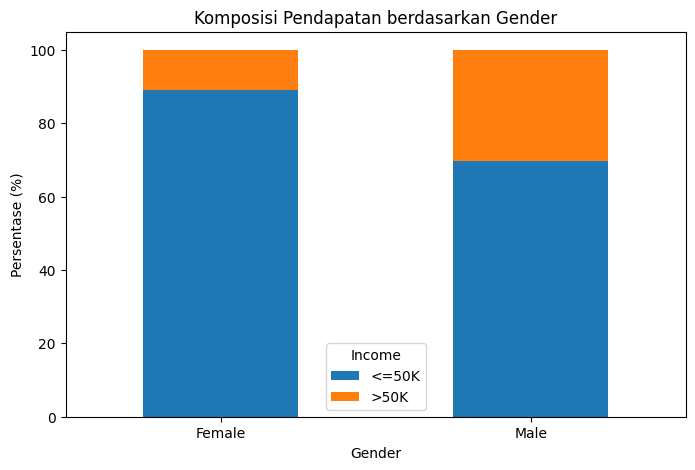

In [22]:
# Grafik 3 — komposisi income berdasarkan gender
income_gender = pd.crosstab(analysis["sex"], analysis["income"], normalize="index") * 100
income_gender.plot(kind="bar", stacked=True)
plt.title("Komposisi Pendapatan berdasarkan Gender")
plt.xlabel("Gender")
plt.ylabel("Persentase (%)")
plt.xticks(rotation=0)
plt.legend(title="Income")
plt.show()

In [23]:
# Ringkasan angka untuk dipakai dalam laporan
print("=== RINGKASAN ANGKA ===")
print("\nGender:")
print(gender_high.round(2))
print("\nRace:")
print(race_high.round(2))
print("\nSelisih gender terbesar:")
print(round(gender_high.max() - gender_high.min(), 2), "poin persentase")
print("\nSelisih race terbesar:")
print(round(race_high.max() - race_high.min(), 2), "poin persentase")

=== RINGKASAN ANGKA ===

Gender:
sex
Female    10.93
Male      30.38
Name: high_income, dtype: float64

Race:
race
Asian-Pac-Islander    26.93
White                 25.40
Other                 12.32
Black                 12.08
Amer-Indian-Eskimo    11.70
Name: high_income, dtype: float64

Selisih gender terbesar:
19.45 poin persentase

Selisih race terbesar:
15.22 poin persentase


## 7. Analisis risiko bias

Perbedaan persentase pada tabel/grafik menunjukkan bahwa kelompok demografis tidak memiliki distribusi income >50K yang sama. Jika pola historis ini langsung dipakai untuk melatih AI persetujuan kredit, model berpotensi menghasilkan keputusan yang tidak setara antar kelompok.

Namun, perbedaan statistik **tidak otomatis membuktikan bahwa model pasti diskriminatif**. Kita perlu mengaudit fitur, proses pelabelan, performa per kelompok, dan kemungkinan *proxy variable*. Contoh proxy adalah variabel yang secara tidak langsung berkaitan erat dengan atribut demografis.

Usulan pengurangan risiko:
1. Audit data sebelum training.
2. Periksa metrik performa per kelompok.
3. Uji fitur yang berpotensi menjadi proxy.
4. Dokumentasikan sumber, batasan, dan tujuan penggunaan data.
5. Jangan menjadikan model sebagai satu-satunya dasar keputusan berisiko tinggi tanpa pengawasan manusia.

## 8. Sumber

Becker, B., & Kohavi, R. (1996). Adult [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5XW20

Materi Pertemuan 1 Machine Learning & AI, Institut Pariwisata Trisakti.